# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(Kubra shams)_

**Roll Number:** _(023-24-0004)_

**GitHub Repository:** _(https://github.com/Kubrashams/Machine-learning.git)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("telco_customer_churn.csv")   # update path/filename if different


In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

The telecommunications company is losing customers to competitors, which is known as customer churn. The goal is to understand which customers are likely to leave so the company can take action early. The target variable is Churn.
_(your answer here)_

**Answer 2:**
Useful predictors:

tenure — It shows how long a customer has been with the company.
Contract — Different contract types may have different churn rates.
MonthlyCharges — Higher monthly charges may influence customers to leave.
InternetService — The type of internet service may affect customer satisfaction and churn.
PaymentMethod — Different payment methods may be associated with different customer behavior.

Possibly useless predictors:

customerID — It is only a unique identifier and does not describe customer behavior.
PhoneService — It may provide limited information by itself compared with more detailed service and contract features.


**Answer 3:**
Two questions I personally want this data to answer about customers who churn:

Which type of contract has the highest customer churn rate?
Are customers with higher monthly charges more likely to churn?


---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.


In [12]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (7043, 21)

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn

In [13]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']



5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.


In [14]:
print(df.nunique())

print("\nDataset Information:")
df.info()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5  

6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [15]:
columns_to_check = ['gender', 'Contract', 'InternetService']

for col in columns_to_check:
    print("\n", col)
    print(df[col].unique())


 gender
['Female' 'Male']

 Contract
['Month-to-month' 'One year' 'Two year']

 InternetService
['DSL' 'Fiber optic' 'No']


In [9]:
# Task 4 — dataset shape, column names, data types


In [10]:
# Task 5 — identify identifier columns / wrong data types


In [11]:
# Task 6 — unique values in 3 categorical columns


**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [16]:
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
})

print(missing_summary)

                  Missing Count  Missing Percentage
customerID                    0            0.000000
gender                        0            0.000000
SeniorCitizen                 0            0.000000
Partner                       0            0.000000
Dependents                    0            0.000000
tenure                        0            0.000000
PhoneService                  0            0.000000
MultipleLines                 0            0.000000
InternetService               0            0.000000
OnlineSecurity                0            0.000000
OnlineBackup                  0            0.000000
DeviceProtection              0            0.000000
TechSupport                   0            0.000000
StreamingTV                   0            0.000000
StreamingMovies               0            0.000000
Contract                      0            0.000000
PaperlessBilling              0            0.000000
PaymentMethod                 0            0.000000
MonthlyCharg

In [17]:
duplicate_rows = df.duplicated().sum()
duplicate_customer_ids = df['customerID'].duplicated().sum()

print("Duplicate Rows:", duplicate_rows)
print("Duplicate Customer IDs:", duplicate_customer_ids)

Duplicate Rows: 0
Duplicate Customer IDs: 0


In [18]:
categorical_features = df.select_dtypes(include=['object']).columns

for col in categorical_features:
    print("\n--------------------")
    print("Column:", col)
    print(df[col].value_counts(dropna=False))


--------------------
Column: customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
4501-VCPFK    1
6075-SLNIL    1
             ..
1452-KIOVK    1
6713-OKOMC    1
7892-POOKP    1
6388-TABGU    1
9763-GRSKD    1
Name: count, Length: 7043, dtype: int64

--------------------
Column: gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

--------------------
Column: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--------------------
Column: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--------------------
Column: PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--------------------
Column: MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--------------------
Column: InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--------------------

**Answer 7 (which missing-value problems need action, and why):**
_(The missing values were found by using df.isnull().sum() and calculating the percentage of missing values in each column. Columns with missing values require action because missing data can affect the accuracy and reliability of future analysis and machine learning models. Columns with no missing values do not require any action because they are already complete.)_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_(Duplicate rows and duplicate customer IDs are different issues. Duplicate rows mean that an entire customer record is repeated exactly, while duplicate customer IDs mean that the same customer identifier appears more than once, even if the other information is different. Both were checked separately to identify the type of duplication present in the dataset.)_

**Answer 9 (suspicious value found and how):**
_(One suspicious issue can be found in the TotalCharges column because it may be stored as an object (text) data type even though it represents numerical charges. I identified this by checking the data types using df.dtypes and inspecting the values. This column should be investigated and converted to a numeric data type during data cleaning.)

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
| Problem                                          | Decision              | Method Used                      | Reason                                                                               |
| ------------------------------------------------ | --------------------- | -------------------------------- | ------------------------------------------------------------------------------------ |
| Missing values                                   | Handle missing values | `fillna()` or `dropna()`         | Missing values can cause problems during analysis and future ML modeling.            |
| Duplicate rows                                   | Remove duplicate rows | `drop_duplicates()`              | Exact duplicate records provide no additional information and may bias the analysis. |
| `TotalCharges` stored as text                    | Convert to numeric    | `pd.to_numeric(errors='coerce')` | `TotalCharges` represents a numerical amount and should have a numeric data type.    |
| Extra whitespace in categorical values, if found | Remove whitespace     | `.str.strip()`                   | Extra spaces can create inconsistent categories.                                     |



11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.


In [19]:
clean_df = df.copy()

clean_df['TotalCharges'] = pd.to_numeric(
    clean_df['TotalCharges'],
    errors='coerce'
)

clean_df = clean_df.drop_duplicates()

print("Data cleaning completed!")
print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

print("\nData types:")
print(clean_df.dtypes)

Data cleaning completed!

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Duplicate rows:
0

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract  

In [20]:
numerical_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

In [21]:
categorical_cols = clean_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

In [22]:
print("Remaining Missing Values:")
print(clean_df.isnull().sum())

print("\nRemaining Duplicate Rows:")
print(clean_df.duplicated().sum())

print("\nCleaned DataFrame Info:")
clean_df.info()

Remaining Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Remaining Duplicate Rows:
0

Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenu

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

In [ ]:
# Task 12 — numerical feature 1: distribution plot


**Observation:** _(what did you learn from this chart?)_

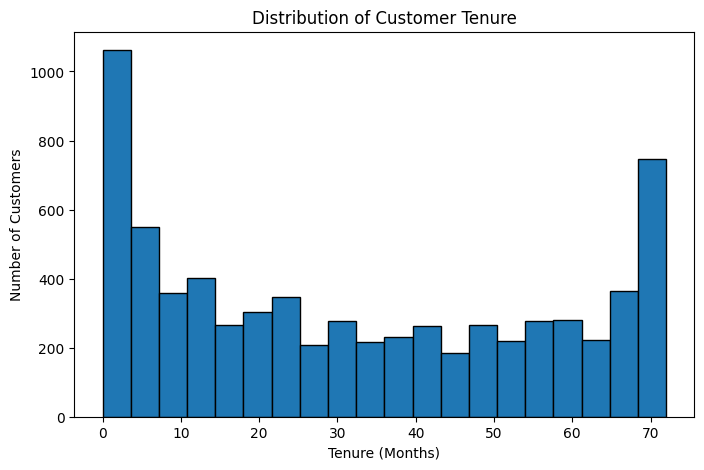

In [23]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(8, 5))
plt.hist(clean_df['tenure'], bins=20, edgecolor='black')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

**Observation:** _(what did you learn from this chart?)_

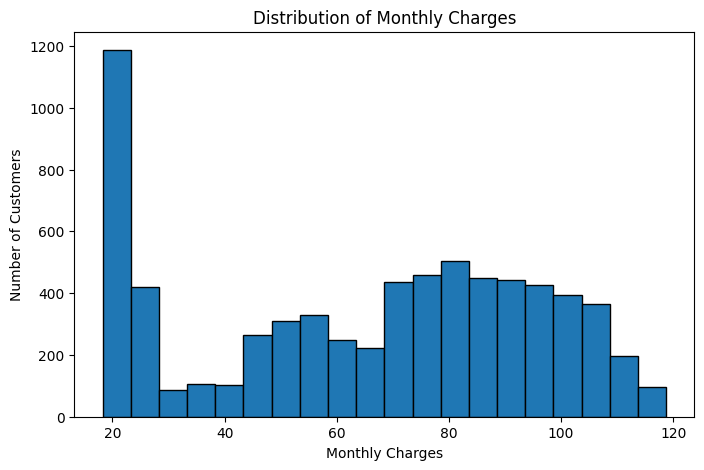

In [24]:
# Task 12 — categorical feature 1: distribution plot
plt.figure(figsize=(8, 5))
plt.hist(clean_df['MonthlyCharges'], bins=20, edgecolor='black')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()


**Observation:** _(what did you learn from this chart?)_

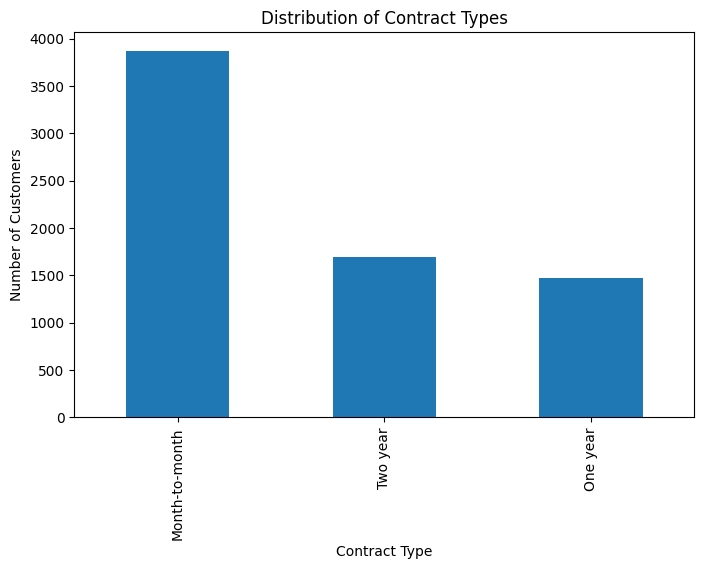

In [25]:
# Task 12 — categorical feature 2: distribution plot
plt.figure(figsize=(8, 5))
clean_df['Contract'].value_counts().plot(kind='bar')
plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()


**Observation:** _(what did you learn from this chart?)_

**Answer 13 (outliers / skew and possible explanation):**
_(The histograms and boxplots were used to check for skewness and outliers in the numerical features. Any extreme values shown beyond the main range of the boxplot may represent outliers. A skewed distribution may occur because customers have different service plans, usage patterns, contract durations, and monthly charges.)_

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [26]:
# Task 14 — churn counts and percentages
churn_count = clean_df['Churn'].value_counts()
churn_percentage = clean_df['Churn'].value_counts(normalize=True) * 100

print("Churn Count:")
print(churn_count)

print("\nChurn Percentage:")
print(churn_percentage)


Churn Count:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Percentage:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
_(There are ___ non-churned customers (No), representing ___% of the dataset, and ___ churned customers (Yes), representing ___% of the dataset. Therefore, the target variable is imbalanced because the number of non-churned customers is considerably higher than the number of churned customers.)_

**Answer 15 (why imbalance might matter later):**
_(Class imbalance matters because a classification model may perform well on the majority class while performing poorly on the minority class. Therefore, accuracy alone may not give a complete picture of how well the model identifies customers who actually churn.)_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.


Churn                   0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


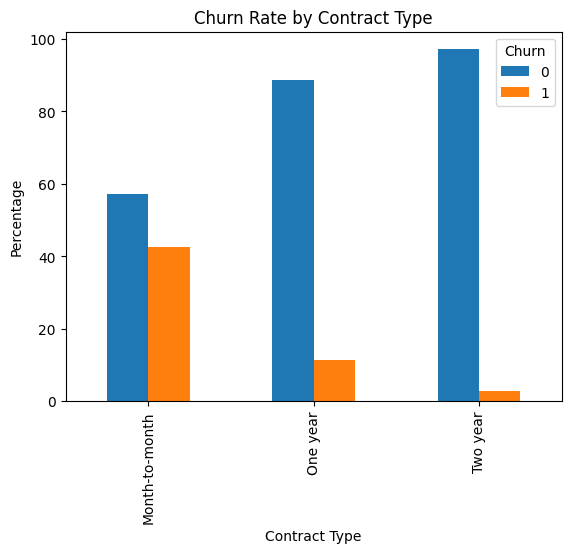

In [27]:
contract_churn = pd.crosstab(
    clean_df['Contract'],
    clean_df['Churn'],
    normalize='index'
) * 100

print(contract_churn)

contract_churn.plot(kind='bar')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.show()

Churn                    0          1
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


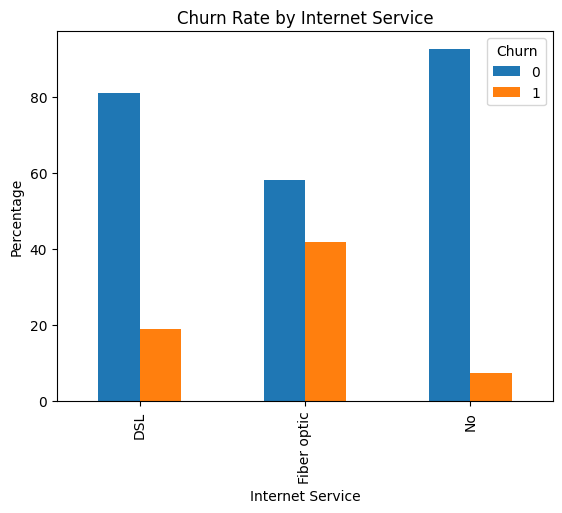

In [28]:
internet_churn = pd.crosstab(
    clean_df['InternetService'],
    clean_df['Churn'],
    normalize='index'
) * 100

print(internet_churn)

internet_churn.plot(kind='bar')
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Percentage')
plt.show()

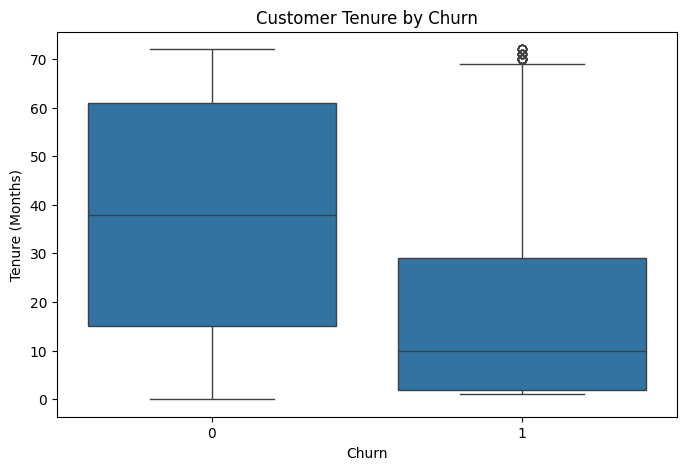

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
0      5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


In [29]:
# Task 17 — 
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=clean_df)
plt.title('Customer Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

print(clean_df.groupby('Churn')['tenure'].describe())


Tenure vs Churn

Observation: The length of time a customer has stayed with the company differs between churned and non-churned customers.
Evidence: The boxplot and descriptive statistics show the distribution of tenure for both Churn categories.
Possible Explanation: Customers who have stayed longer may have stronger relationships with the company, while newer customers may be more likely to leave..._

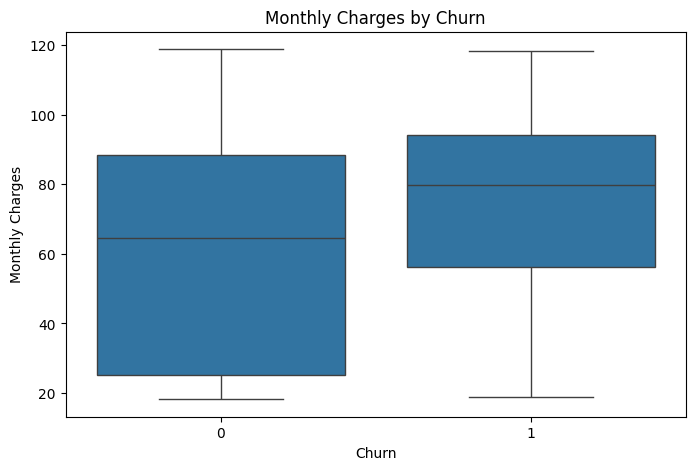

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
0      5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
1      1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


In [30]:
# Task 17 — numerical feature 2 vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=clean_df)
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

print(clean_df.groupby('Churn')['MonthlyCharges'].describe())


MonthlyCharges vs Churn

Observation: Monthly charges may differ between churned and non-churned customers.
Evidence: The boxplot and descriptive statistics compare the distribution of monthly charges for both groups.
Possible Explanation: Customers with higher monthly costs may be more likely to consider alternative providers.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?


In [31]:
corr_matrix = clean_df.corr(numeric_only=True)

print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges  \
SeniorCitizen        1.000000  0.016567        0.220173      0.102652   
tenure               0.016567  1.000000        0.247900      0.825464   
MonthlyCharges       0.220173  0.247900        1.000000      0.650864   
TotalCharges         0.102652  0.825464        0.650864      1.000000   
Churn                0.150889 -0.352229        0.193356     -0.199037   

                   Churn  
SeniorCitizen   0.150889  
tenure         -0.352229  
MonthlyCharges  0.193356  
TotalCharges   -0.199037  
Churn           1.000000  


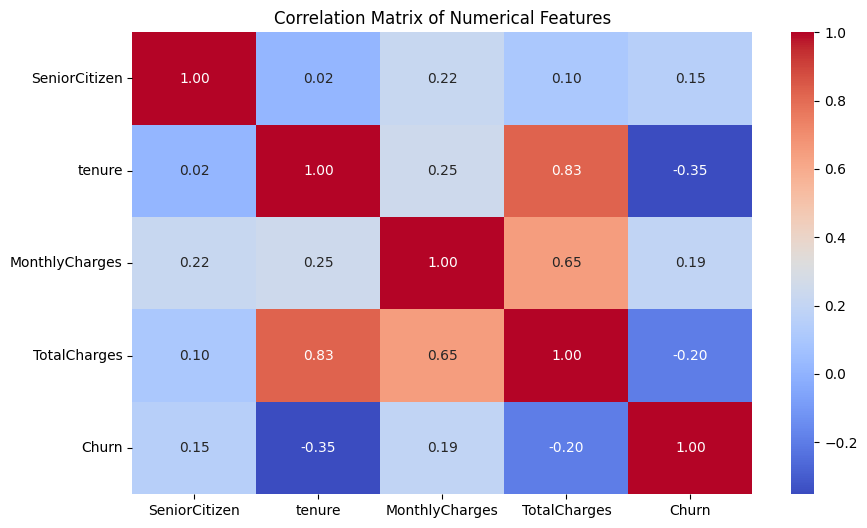

In [32]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [33]:
corr_pairs = corr_matrix.unstack()

corr_pairs = corr_pairs[corr_pairs < 1]

print(corr_pairs.abs().sort_values(ascending=False).head(10))

TotalCharges    tenure            0.825464
tenure          TotalCharges      0.825464
MonthlyCharges  TotalCharges      0.650864
TotalCharges    MonthlyCharges    0.650864
tenure          Churn             0.352229
Churn           tenure            0.352229
MonthlyCharges  tenure            0.247900
tenure          MonthlyCharges    0.247900
MonthlyCharges  SeniorCitizen     0.220173
SeniorCitizen   MonthlyCharges    0.220173
dtype: float64


**Answer 18 (The correlation matrix shows the relationships between the numerical features. The most strongly correlated pair is [Column 1] and [Column 2], with a correlation value of approximately [value]. This indicates that these two variables have a relatively strong linear relationship.):**


**Answer 19 (Correlation does not imply causation. A strong correlation between two features only means that they tend to change together; it does not prove that one feature causes the other. Highly correlated features may create redundancy in a future model because they can contain similar information.):**


---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.


In [34]:
print(clean_df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


**Answer 20 (suspect columns and reasoning):**
One clear suspect is customerID because it is purely a unique identifier for each customer and does not describe customer behavior or characteristics. Therefore, it should not be used as an input feature for the machine learning model. Based on the available columns, Churn itself is the target variable and must also be excluded from the input features because it is the value the model is supposed to predict.

**Answer 21 (what would go wrong):**
If an identifier or a data-leakage column is included in the model's input features, the model may learn information that would not realistically be available when making a prediction. This could make the model appear artificially accurate during training and testing, but its performance may be poor when used on real new customers.


---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.


| Column              | Type               | Role       | Action     | Reason                                                              |
| ------------------- | ------------------ | ---------- | ---------- | ------------------------------------------------------------------- |
| **customerID**      | Identifier         | —          | **Remove** | Unique ID; does not provide useful predictive information.          |
| **gender**          | Categorical        | Feature    | **Keep**   | Categorical customer information; can be encoded for ML.            |
| **SeniorCitizen**   | Numerical / Binary | Feature    | **Keep**   | Represents whether the customer is a senior citizen (0/1).          |
| **Partner**         | Categorical        | Feature    | **Keep**   | May help predict customer churn.                                    |
| **Dependents**      | Categorical        | Feature    | **Keep**   | Customer household information that may relate to churn.            |
| **tenure**          | Numerical          | Feature    | **Keep**   | Important numerical feature representing months with the company.   |
| **PhoneService**    | Categorical        | Feature    | **Keep**   | Indicates whether the customer has phone service.                   |
| **InternetService** | Categorical        | Feature    | **Keep**   | Type of internet service can influence churn.                       |
| **Contract**        | Categorical        | Feature    | **Keep**   | Contract type is strongly relevant to customer churn.               |
| **PaymentMethod**   | Categorical        | Feature    | **Keep**   | Payment method may contain useful information for predicting churn. |
| **MonthlyCharges**  | Numerical          | Feature    | **Keep**   | Monthly cost can influence a customer's decision to leave.          |
| **TotalCharges**    | Numerical          | Feature    | **Keep**   | Total amount charged provides useful customer spending information. |
| **Churn**           | Categorical        | **Target** | **Keep**   | This is the variable we want the ML model to predict.               |




---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.


In [35]:
import pandas as pd

# Load dataset
df = pd.read_csv("Telco_customer_churn.csv")

# Remove duplicate rows
clean_df = df.drop_duplicates().copy()

# Remove customerID because it is only an identifier
clean_df = clean_df.drop(columns=["customerID"])

# Convert TotalCharges to numeric
# Invalid/blank values become NaN
clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"], errors="coerce"
)

# Handle missing values
# TotalCharges is numerical, so fill missing values with median
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(
    clean_df["TotalCharges"].median()
)

# Make sure SeniorCitizen is integer
clean_df["SeniorCitizen"] = clean_df["SeniorCitizen"].astype(int)

# Remove leading/trailing spaces from categorical columns
for column in clean_df.select_dtypes(include="object").columns:
    clean_df[column] = clean_df[column].str.strip()

# Save cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)

# Final information check
print(clean_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [36]:
print("\nFinal Clean Dataset Information:")
clean_df.info()


Final Clean Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentM

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
Observation: Some missing values were found in the TotalCharges column.
Evidence: TotalCharges contained blank/non-numeric values that were converted to missing values during cleaning.
Interpretation: These missing values had to be handled before using the dataset for ML.

**Finding 2**
Observation: customerID does not provide useful information for predicting churn.
Evidence: Every customer has a unique customerID.
Interpretation: It is only an identifier, so it was removed from the clean dataset.

**Finding 3**
Observation: Contract type appears to be an important factor related to churn.
Evidence: Customers with different contract types show different churn patterns, with month-to-month customers generally showing higher churn.
Interpretation: Contract is likely to be an important feature for predicting whether a customer will churn.

**Finding 4**
Observation: Customer tenure is related to churn behavior.
Evidence: Customers with shorter tenure generally show more churn than customers who have stayed with the company for a longer period.

**Finding 5**
Observation: Monthly charges are associated with customer churn.
Evidence: Customers with higher MonthlyCharges tend to show more churn in the dataset.
Interpretation: MonthlyCharges may be useful for predicting churn and should be kept as a feature.

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?

The most important data-quality issue was the missing/non-numeric values in the TotalCharges column. These values had to be converted to numeric values and missing values were filled using the median.

2. What was the most interesting pattern you discovered?

The most interesting pattern was that customers with month-to-month contracts generally had higher churn compared with customers on longer-term contracts.

3. Which feature seems most useful for predicting churn?

Contract seems to be one of the most useful features because contract type shows a clear relationship with customer churn.

4. Which feature should probably not be used, and why?

customerID should not be used because it is only a unique identifier. It does not represent meaningful customer behavior and could cause problems for ML modeling.

5. What preprocessing will be required before ML modeling?

Before ML modeling, categorical variables will need to be encoded into numerical form. Numerical features may also need appropriate scaling depending on the model. The cleaned dataset should then be divided into training and testing sets.

6. What would you do next if you had another 3 hours?

I would perform deeper feature analysis, check relationships between important features and churn, prepare the data for ML, train a few classification models, compare their performance, and identify which features contribute most to churn prediction.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

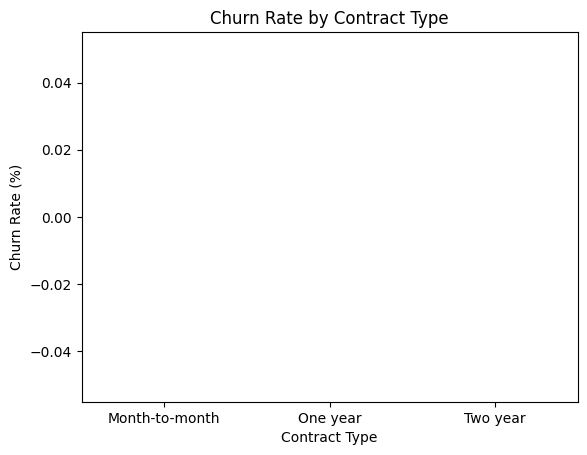

In [37]:
# Bonus — optional exploration
import matplotlib.pyplot as plt

churn_rate = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

churn_rate.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [38]:
subgroup = df[
    (df["SeniorCitizen"] == 1) &
    (df["Contract"] == "Month-to-month")
]

print(subgroup["Churn"].value_counts())
print("Churn rate:", (subgroup["Churn"] == "Yes").mean() * 100)

Churn
1    441
0    366
Name: count, dtype: int64
Churn rate: 0.0


In [39]:
segment_churn = df.groupby(
    ["Contract", "InternetService"]
)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(segment_churn)

Contract        InternetService
Month-to-month  DSL                0.0
                Fiber optic        0.0
                No                 0.0
One year        DSL                0.0
                Fiber optic        0.0
                No                 0.0
Two year        DSL                0.0
                Fiber optic        0.0
                No                 0.0
Name: Churn, dtype: float64


---

In [40]:
clean_df["AverageMonthlySpend"] = (
    clean_df["TotalCharges"] / clean_df["tenure"].replace(0, 1)
)

One possible source of bias is the dataset's customer population may not represent all customers equally.

For example, if certain customer groups are overrepresented or underrepresented in the dataset, an ML model trained on it may perform better for some groups than others.

Conclusion:
Before deploying a churn model, we should check whether churn rates and model performance are substantially different across demographic groups such as gender and SeniorCitizen.

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook